# Classification

## Setup

In [7]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as st
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

In [11]:
!pip install -q scikit-learn-intelex
from sklearnex import patch_sklearn
patch_sklearn()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 MB 9.0 MB/s eta 0:00:00


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## Load Data

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
X, y = mnist["data"], mnist["target"]

In [3]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 70000 entries, 0 to 69999
Series name: class
Non-Null Count  Dtype   
--------------  -----   
70000 non-null  category
dtypes: category(1)
memory usage: 68.9 KB


## Utils

In [22]:
def plot_two_parameters_vs_score(rs, param_group_by, second_param, score):
  df = pd.DataFrame(rs.cv_results_)

  for w, sub in df.groupby(param_group_by):
      plt.plot(sub[second_param].astype(int),
              sub[score],
              marker="o",
              label=f"{param_group_by}={w}")

  plt.xlabel(second_param)
  plt.ylabel(score)
  plt.title(f"{second_param} vs {score} by {param_group_by}")
  plt.legend()
  plt.grid(True)
  plt.show()

In [23]:
def plot_parameter_vs_score(rs, parameter, score):

  # Get CV results into a DataFrame
  df = pd.DataFrame(rs.cv_results_)

  # Extract relevant columns
  df_plot = df[[parameter, score]].copy()

  # Convert param column to int (sometimes it's string/object)
  df_plot[parameter] = df_plot[parameter].astype(int)

  # Sort so the plot looks nice
  df_plot = df_plot.sort_values(parameter)

  plt.figure(figsize=(6,4))
  plt.plot(df_plot[parameter], df_plot[score], marker="o")
  plt.xlabel(parameter)
  plt.ylabel(score)
  plt.title("parameter vs score (from RandomizedSearchCV)")
  plt.grid(True)
  plt.show()

## KNeighborsClassifier

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, stratify=y, random_state=42
)

In [6]:
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index() * 100
test_dist  = pd.Series(y_test).value_counts(normalize=True).sort_index() * 100

df = pd.DataFrame({
    "train %": train_dist.round(2),
    "test %":  test_dist.round(2)
})

print(df)

       train %  test %
class                 
0         9.86    9.86
1        11.25   11.25
2         9.98    9.99
3        10.20   10.20
4         9.75    9.75
5         9.02    9.02
6         9.82    9.82
7        10.42   10.42
8         9.75    9.75
9         9.94    9.94


### First Try

In [10]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    # Note : quantization does not speed up much kNN, PCA does
    # ("pca", PCA(svd_solver="full")),
    ("knn", KNeighborsClassifier(algorithm="brute", n_jobs=1))
])

In [8]:
param_dist = {
    # "pca__n_components": st.uniform(0.90, 0.10),   # sample between 0.90–1.00 variance
    "knn__n_neighbors": st.randint(50, 150),        # sample 3–9 neighbors
    "knn__weights": ["uniform", "distance"],
    "knn__p": [2],                                # could add 1 if you want Manhattan too
}

rs = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=20,          # try 8–20 depending on time
    cv=3,
    n_jobs=-1,
    scoring="accuracy",
    random_state=42,
    verbose=1
)
rs.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('knn',
                                              KNeighborsClassifier(algorithm='brute',
                                                                   n_jobs=1))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'knn__n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ecf738ed730>,
                                        'knn__p': [2],
                                        'knn__weights': ['uniform',
                                                         'distance']},
                   random_state=42, scoring='accuracy', verbose=1)

In [9]:
print("Best params:", rs.best_params_)
print("CV best score:", rs.best_score_)
print("Test acc:", rs.score(X_test, y_test))

Best params: {'knn__n_neighbors': 4, 'knn__p': 2, 'knn__weights': 'distance'}
CV best score: 0.9455166666666667
Test acc: 0.9498


In [10]:
rs.cv_results_

{'mean_fit_time': array([1.56370894, 1.66914781, 1.42868352, 1.37484376, 1.78689305,
        1.25637595, 1.21142085, 1.77233871, 1.39253807, 1.19674222,
        1.20758041, 1.73950179, 1.26977452, 1.20590536, 1.68697604,
        1.25179784, 1.18783689, 1.29461694, 1.61644689, 1.20425924]),
 'std_fit_time': array([0.12755556, 0.10869226, 0.0529383 , 0.00821539, 0.30555282,
        0.07899945, 0.00303784, 0.18870457, 0.2875988 , 0.01582949,
        0.00047619, 0.3942028 , 0.09466096, 0.01000132, 0.35982468,
        0.05703181, 0.00658108, 0.13174401, 0.25758529, 0.02672053]),
 'mean_score_time': array([100.44606233,  98.52104926,  98.29919481,  98.16801214,
         98.40815568,  98.53815873,  99.31719406,  97.27934027,
         98.18726937,  97.75432714,  98.58960756,  98.2062161 ,
         98.30184984,  98.46201952,  98.65227763,  97.62763786,
         98.22246305,  98.6389668 ,  98.74634965,  98.0417215 ]),
 'std_score_time': array([0.75514624, 0.3573965 , 0.04358097, 0.20261495, 0.48

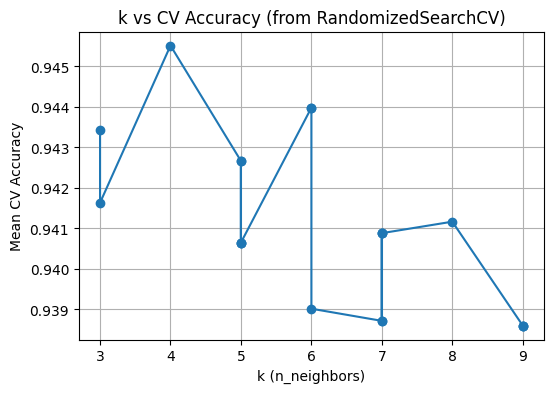

    param_knn__n_neighbors  mean_test_score
13                       3         0.943433
16                       3         0.941633
14                       4         0.945517
2                        5         0.942667
6                        5         0.940650
8                        5         0.942667
17                       5         0.940650
5                        5         0.940650
10                       6         0.943983
19                       6         0.943983
12                       6         0.939017
1                        7         0.938717
15                       7         0.940883
9                        7         0.940883
3                        7         0.938717
7                        7         0.940883
11                       8         0.941167
4                        9         0.938600
0                        9         0.938600
18                       9         0.938600


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Get CV results into a DataFrame
df = pd.DataFrame(rs.cv_results_)

# Extract relevant columns
df_plot = df[["param_knn__n_neighbors", "mean_test_score"]].copy()

# Convert param column to int (sometimes it's string/object)
df_plot["param_knn__n_neighbors"] = df_plot["param_knn__n_neighbors"].astype(int)

# Sort so the plot looks nice
df_plot = df_plot.sort_values("param_knn__n_neighbors")

# Plot
plt.figure(figsize=(6,4))
plt.plot(df_plot["param_knn__n_neighbors"], df_plot["mean_test_score"], marker="o")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV Accuracy")
plt.title("k vs CV Accuracy (from RandomizedSearchCV)")
plt.grid(True)
plt.show()

print(df_plot)


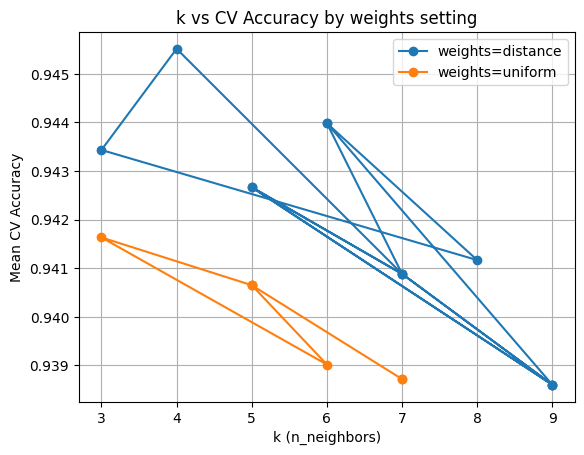

In [12]:
for w, sub in df.groupby("param_knn__weights"):
    plt.plot(sub["param_knn__n_neighbors"].astype(int),
             sub["mean_test_score"],
             marker="o",
             label=f"weights={w}")

plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV Accuracy")
plt.title("k vs CV Accuracy by weights setting")
plt.legend()
plt.grid(True)
plt.show()


### Second Try

In [13]:
param_dist = {
    "knn__n_neighbors": st.randint(50, 150),
    "knn__weights": ["distance"],
    "knn__p": [2],
}

rs = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    n_jobs=-1,
    scoring="accuracy",
    random_state=42,
    verbose=1
)
rs.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('knn',
                                              KNeighborsClassifier(algorithm='brute',
                                                                   n_jobs=1))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'knn__n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ecf72578b90>,
                                        'knn__p': [2],
                                        'knn__weights': ['distance']},
                   random_state=42, scoring='accuracy', verbose=1)

In [14]:
print("Best params:", rs.best_params_)
print("CV best score:", rs.best_score_)
print("Test acc:", rs.score(X_test, y_test))

Best params: {'knn__n_neighbors': 51, 'knn__p': 2, 'knn__weights': 'distance'}
CV best score: 0.9148833333333334
Test acc: 0.9196


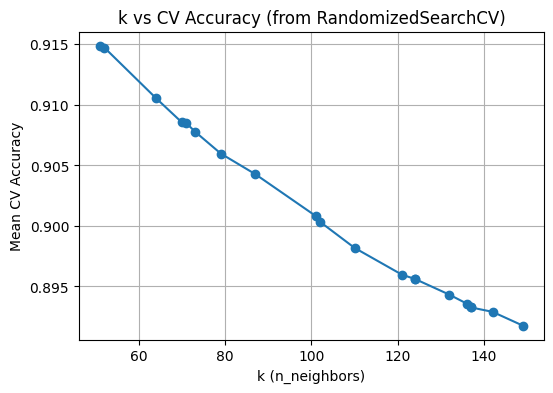

    param_knn__n_neighbors  mean_test_score
16                      51         0.914883
13                      52         0.914717
2                       64         0.910533
5                       70         0.908533
14                      71         0.908483
12                      73         0.907783
18                      79         0.905967
19                      87         0.904267
0                      101         0.900817
15                     102         0.900333
4                      110         0.898183
3                      121         0.895967
8                      124         0.895617
9                      124         0.895617
6                      132         0.894317
7                      136         0.893583
10                     137         0.893267
17                     137         0.893267
1                      142         0.892900
11                     149         0.891767


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Get CV results into a DataFrame
df = pd.DataFrame(rs.cv_results_)

# Extract relevant columns
df_plot = df[["param_knn__n_neighbors", "mean_test_score"]].copy()

# Convert param column to int (sometimes it's string/object)
df_plot["param_knn__n_neighbors"] = df_plot["param_knn__n_neighbors"].astype(int)

# Sort so the plot looks nice
df_plot = df_plot.sort_values("param_knn__n_neighbors")

# Plot
plt.figure(figsize=(6,4))
plt.plot(df_plot["param_knn__n_neighbors"], df_plot["mean_test_score"], marker="o")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV Accuracy")
plt.title("k vs CV Accuracy (from RandomizedSearchCV)")
plt.grid(True)
plt.show()

print(df_plot)


3d try:

In [12]:
param_dist = {
    "knn__n_neighbors": st.randint(4, 50),
    "knn__weights": ["distance"],
    "knn__p": [1, 2],
}

rs = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=15,
    cv=2,
    n_jobs=-1,
    scoring="accuracy",
    random_state=42,
    verbose=1
)
rs.fit(X_train, y_train)

Fitting 2 folds for each of 15 candidates, totalling 30 fits


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('knn',
                                              KNeighborsClassifier(algorithm='brute',
                                                                   n_jobs=1))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'knn__n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7edc50e8d790>,
                                        'knn__p': [1, 2],
                                        'knn__weights': ['distance']},
                   random_state=42, scoring='accuracy', verbose=1)

In [13]:
print("Best params:", rs.best_params_)
print("CV best score:", rs.best_score_)
print("Test acc:", rs.score(X_test, y_test))

Best params: {'knn__n_neighbors': 14, 'knn__p': 1, 'knn__weights': 'distance'}
CV best score: 0.9206000000000001
Test acc: 0.93642


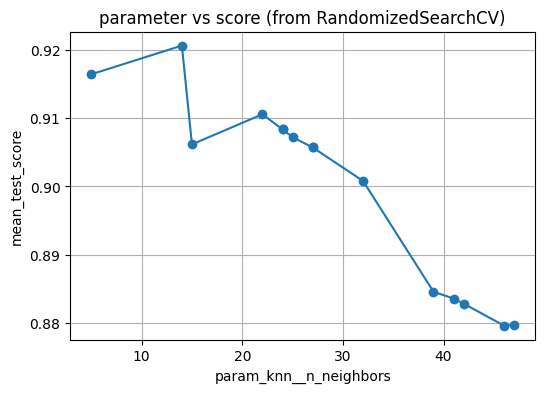

In [19]:
def plot_parameter_vs_score(rs, parameter, score):

  # Get CV results into a DataFrame
  df = pd.DataFrame(rs.cv_results_)

  # Extract relevant columns
  df_plot = df[[parameter, score]].copy()

  # Convert param column to int (sometimes it's string/object)
  df_plot[parameter] = df_plot[parameter].astype(int)

  # Sort so the plot looks nice
  df_plot = df_plot.sort_values(parameter)

  plt.figure(figsize=(6,4))
  plt.plot(df_plot[parameter], df_plot[score], marker="o")
  plt.xlabel(parameter)
  plt.ylabel(score)
  plt.title("parameter vs score (from RandomizedSearchCV)")
  plt.grid(True)
  plt.show()

plot_parameter_vs_score(rs, "param_knn__n_neighbors", "mean_test_score")

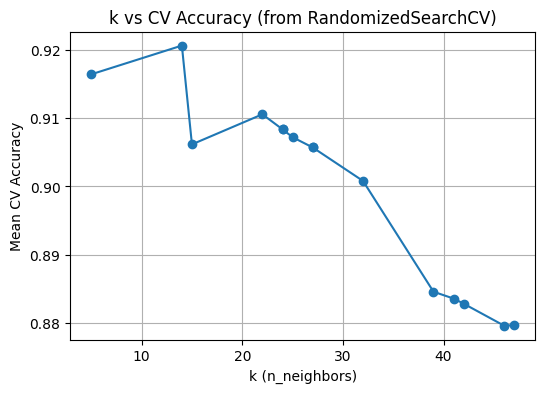

    param_knn__n_neighbors  mean_test_score
10                       5          0.91640
5                       14          0.92060
14                      15          0.90615
4                       22          0.91055
3                       24          0.90835
13                      24          0.90835
9                       25          0.90720
6                       27          0.90570
8                       27          0.90570
1                       32          0.90080
7                       39          0.88460
12                      41          0.88360
0                       42          0.88285
2                       46          0.87965
11                      47          0.87970


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Get CV results into a DataFrame
df = pd.DataFrame(rs.cv_results_)

# Extract relevant columns
df_plot = df[["param_knn__n_neighbors", "mean_test_score"]].copy()

# Convert param column to int (sometimes it's string/object)
df_plot["param_knn__n_neighbors"] = df_plot["param_knn__n_neighbors"].astype(int)



# Plot
plt.figure(figsize=(6,4))
plt.plot(df_plot["param_knn__n_neighbors"], df_plot["mean_test_score"], marker="o")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV Accuracy")
plt.title("k vs CV Accuracy (from RandomizedSearchCV)")
plt.grid(True)
plt.show()

print(df_plot)


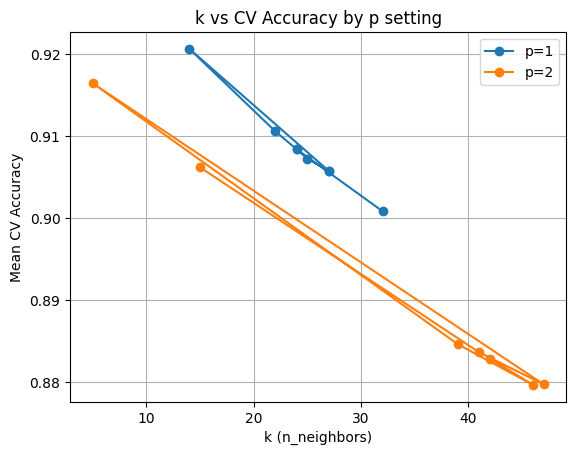

In [18]:
plot_two_parameters_vs_score(rs, "param_knn__p", "param_knn__n_neighbors",
                             "mean_test_score")


### Thrid try

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, stratify=y, random_state=42
)